Non-nan rows: 1000
HARISS inf rows imputed: 0; rows: 1000
Mean AWW CTT1: 24.008  95%: (10, 34)
Mean AWW CTT2: 32.627  95%: (16, 41)
Mean ICU: 40.243410042252144  95%: (17, 60.3)
Mean HARISS: 34.81400049253223  95%: (19.5, 43.5)
Earliest (CTT1): 23.1  95%: (9.3, 33.5)
Earliest (CTT2): 29.2  95%: (12.5, 39)
Mean max−earliest: 20  95%: (4.6, 40.7)


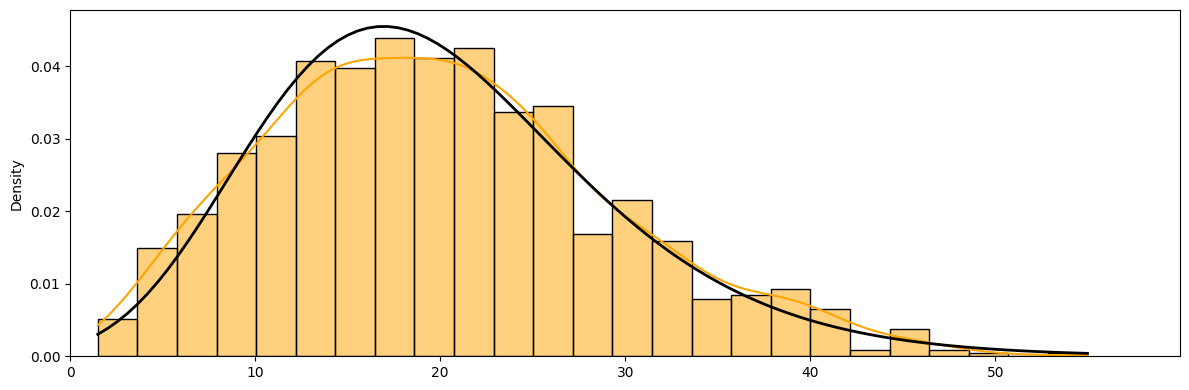

/var/folders/p4/bkq4723d15zg3x67hd8cz0tw0000gp/T/ipykernel_73350/1150616442.py:153: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend().set_visible(False)
/var/folders/p4/bkq4723d15zg3x67hd8cz0tw0000gp/T/ipykernel_73350/1150616442.py:185: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend().set_visible(False)


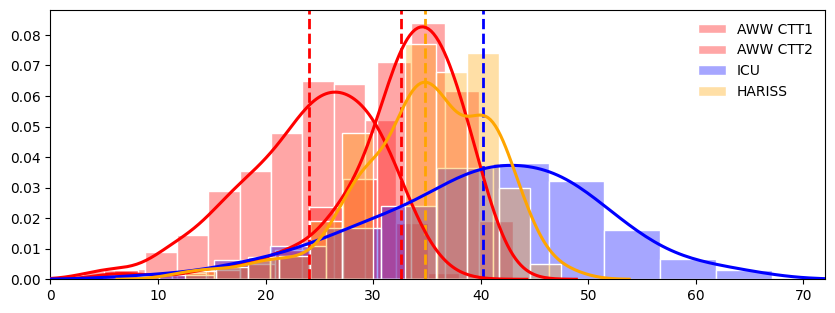

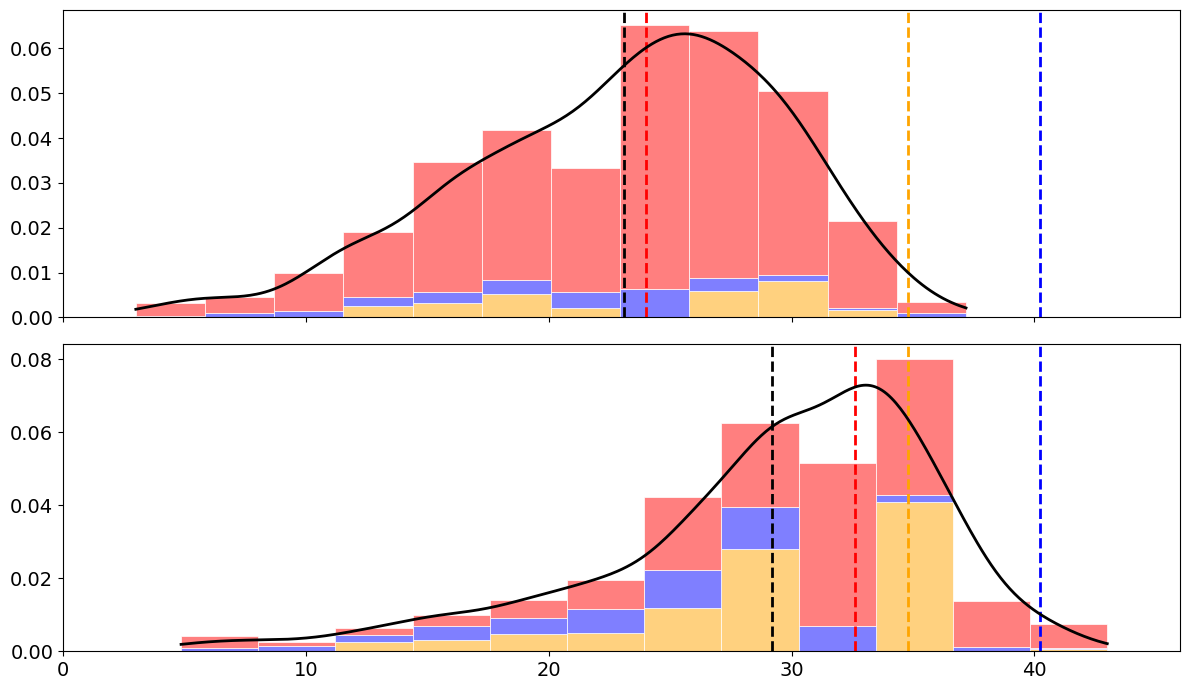

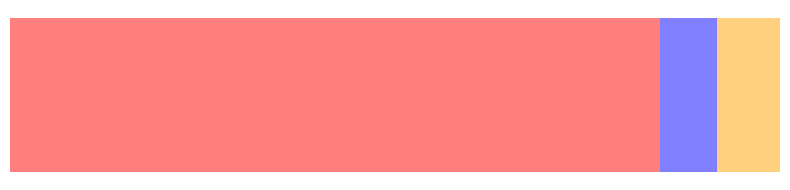

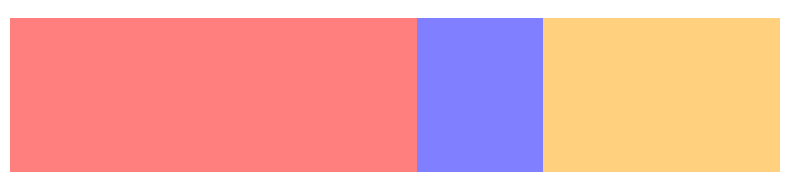

In [4]:
# CTT multitype: AWW CTT1, AWW CTT2, ICU, HARISS; earliest-time panels; max→earliest spread
# CSV columns use surveillance labels AWW / ICU / HARISS (two AWW *streams* = CTT1/CTT2 times).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

# _CSV = Path("/Users/reddy/AWW_and_ICU/global_model/pgfgleam/all_results/local/multitype_comparison_samples_ctt_2.0_4.csv")
type = "2.0_4"
_CSV = Path(f"/Users/reddy/AWW_and_ICU/global_model/pgfgleam/all_results/local/multitype_comparison_samples_ctt_{type}.csv")
assert _CSV.is_file(), f"CSV not found: {_CSV}"
data = pd.read_csv(_CSV)

data = data[data["hariss_detection_time"] < np.inf]
data = data[data["aww_ctt2_detection_time"] < np.inf]
print(f"Non-nan rows: {len(data)}")

# Impute HARISS non-detect (inf) for finite max / KDEs
_n_inf = int(np.isinf(data["hariss_detection_time"].to_numpy()).sum())
data_finite = data[np.isfinite(data["hariss_detection_time"])]
if len(data_finite) > 0:
    _cap = 7.0 + float(data_finite["hariss_detection_time"].max())
    data = data.copy()
    data.loc[np.isinf(data["hariss_detection_time"]), "hariss_detection_time"] = _cap
print(f"HARISS inf rows imputed: {_n_inf}; rows: {len(data)}")

# Actually if HARISS has nan, remove the row



fpr = data["false_positive_rate"]
aww_ctt1_det_samples = data["aww_ctt1_detection_time"]
aww_ctt2_det_samples = data["aww_ctt2_detection_time"]
icu_det_samples = data["icu_detection_time"]
hariss_det_samples = data["hariss_detection_time"]
earliest_ctt1_det_samples = data["earliest_detection_time_ctt1"]
earliest_ctt2_det_samples = data["earliest_detection_time_ctt2"]
earliest_ctt1_surveillance_type_samples = data["earliest_surveillance_type_ctt1"]
earliest_ctt2_surveillance_type_samples = data["earliest_surveillance_type_ctt2"]


def _f(x):
    a = np.asarray(pd.to_numeric(x, errors="coerce"), dtype=float)
    return a[np.isfinite(a)]


_c1, _c2, _ic, _ha = (
    _f(aww_ctt1_det_samples),
    _f(aww_ctt2_det_samples),
    _f(icu_det_samples),
    _f(hariss_det_samples),
)
_t_all = np.r_[_c1, _c2, _ic, _ha]
_c_ctt1, _c_ctt2 = 'red', 'red'

qlo, qhi = 0.025, 0.975
print(f"Mean AWW CTT1: {aww_ctt1_det_samples.mean()}  95%: ({aww_ctt1_det_samples.quantile(qlo):.3g}, {aww_ctt1_det_samples.quantile(qhi):.3g})")
print(f"Mean AWW CTT2: {aww_ctt2_det_samples.mean()}  95%: ({aww_ctt2_det_samples.quantile(qlo):.3g}, {aww_ctt2_det_samples.quantile(qhi):.3g})")
print(f"Mean ICU: {icu_det_samples.mean()}  95%: ({icu_det_samples.quantile(qlo):.3g}, {icu_det_samples.quantile(qhi):.3g})")
print(f"Mean HARISS: {hariss_det_samples.mean()}  95%: ({hariss_det_samples.quantile(qlo):.3g}, {hariss_det_samples.quantile(qhi):.3g})")
print(
    f"Earliest (CTT1): {earliest_ctt1_det_samples.mean():.3g}  95%: ({earliest_ctt1_det_samples.quantile(qlo):.3g}, {earliest_ctt1_det_samples.quantile(qhi):.3g})"
)
print(
    f"Earliest (CTT2): {earliest_ctt2_det_samples.mean():.3g}  95%: ({earliest_ctt2_det_samples.quantile(qlo):.3g}, {earliest_ctt2_det_samples.quantile(qhi):.3g})"
)

# max − min spread vs earliest (CTT1)
differences = []
for _, row in data.iterrows():
    mx = max(
        row["aww_ctt1_detection_time"],
        row["aww_ctt2_detection_time"],
        row["icu_detection_time"],
        row["hariss_detection_time"],
    )
    differences.append(float(mx) - float(row["earliest_detection_time_ctt1"]))

print(
    f"Mean max−earliest: {np.mean(differences):.3g}  95%: ({np.percentile(differences, 2.5):.3g}, {np.percentile(differences, 97.5):.3g})"
)
lognormal_fit = stats.lognorm.fit(differences)
x_pdf = np.linspace(float(np.min(differences)), float(np.max(differences)), 100)
pdf = stats.lognorm.pdf(x_pdf, *lognormal_fit)
fig, ax0 = plt.subplots(1, 1, figsize=(12, 4))
sns.histplot(differences, ax=ax0, bins=25, color="orange", stat="density", kde=True)
ax0.set_ylabel("Density")
ax0.plot(x_pdf, pdf, "k", lw=2)
ax0.set_xlim(0, float(np.max(differences)) + 5.0)
plt.tight_layout()
plt.show()

# Three stacked rows: 4 channel times, earliest@CTT1, earliest@CTT2
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5), sharex=False)
for _arr, _col, _lab in [
    (_c1, _c_ctt1, "AWW CTT1"),
    (_c2, _c_ctt2, "AWW CTT2"),
    (_ic, "blue", "ICU"),
    (_ha, "orange", "HARISS"),
]:
    sns.histplot(
        _arr, ax=ax, bins=12, color=_col, edgecolor="white", alpha=0.35, kde=False, label=_lab, stat="density"
    )
for _arr, _col in [(_c1, _c_ctt1), (_c2, _c_ctt2), (_ic, "blue"), (_ha, "orange")]:
    sns.kdeplot(_arr, ax=ax, color=_col, lw=2.2, clip=(0, None), bw_adjust=1.3, zorder=5)
ax.axvline(_c1.mean(), color=_c_ctt1, ls="--", lw=2, zorder=1)
ax.axvline(_c2.mean(), color=_c_ctt2, ls="--", lw=2, zorder=1)
ax.axvline(_ic.mean(), color="blue", ls="--", lw=2, zorder=1)
ax.axvline(_ha.mean(), color="orange", ls="--", lw=2, zorder=1)
ax.set_ylabel("")
ax.set_xlim(0, float(np.max(_t_all)) + 5.0)
_h, _lab2 = ax.get_legend_handles_labels()
_lmap = dict(zip(_lab2, _h))
ax.legend(_lmap.values(), _lmap.keys(), loc="upper right", frameon=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

type_colors = {"AWW": "red", "ICU": "blue", "HARISS": "orange"}
_n_b = 12
df1 = data[["earliest_detection_time_ctt1", "earliest_surveillance_type_ctt1"]].dropna(
    subset=["earliest_detection_time_ctt1", "earliest_surveillance_type_ctt1"]
)
df1 = df1[np.isfinite(df1["earliest_detection_time_ctt1"])]
sns.histplot(
    data=df1,
    x="earliest_detection_time_ctt1",
    hue="earliest_surveillance_type_ctt1",
    hue_order=["AWW", "ICU", "HARISS"],
    palette=type_colors,
    multiple="stack",
    bins=_n_b,
    ax=axes[0],
    stat="density",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.5,
)
_t1a = df1["earliest_detection_time_ctt1"].to_numpy(dtype=float)
a0, a1 = float(_t1a.min()), float(_t1a.max())
k1 = stats.gaussian_kde(_t1a)
xs1 = np.linspace(a0, a1, 400)
axes[0].plot(xs1, k1(xs1), color="black", lw=2, zorder=5)
axes[0].axvline(_t1a.mean(), color="black", ls="--", lw=2)
axes[0].axvline(_c1.mean(), color=_c_ctt1, ls="--", lw=2, zorder=1)
axes[0].axvline(_ic.mean(), color="blue", ls="--", lw=2, zorder=1)
axes[0].axvline(_ha.mean(), color="orange", ls="--", lw=2, zorder=1)
axes[0].set_xlim(0, float(np.max(_t1a)) + 5.0)
axes[0].set_ylabel("")
axes[0].tick_params(labelsize=14)
axes[0].legend().set_visible(False)

df2 = data[["earliest_detection_time_ctt2", "earliest_surveillance_type_ctt2"]].dropna(
    subset=["earliest_detection_time_ctt2", "earliest_surveillance_type_ctt2"]
)
df2 = df2[np.isfinite(df2["earliest_detection_time_ctt2"])]
sns.histplot(
    data=df2,
    x="earliest_detection_time_ctt2",
    hue="earliest_surveillance_type_ctt2",
    hue_order=["AWW", "ICU", "HARISS"],
    palette=type_colors,
    multiple="stack",
    bins=_n_b,
    ax=axes[1],
    stat="density",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.5,
)
_t2a = df2["earliest_detection_time_ctt2"].to_numpy(dtype=float)
b0, b1 = float(_t2a.min()), float(_t2a.max())
k2 = stats.gaussian_kde(_t2a)
xs2 = np.linspace(b0, b1, 400)
axes[1].plot(xs2, k2(xs2), color="black", lw=2, zorder=5)
axes[1].axvline(_t2a.mean(), color="black", ls="--", lw=2)
axes[1].axvline(_c2.mean(), color=_c_ctt2, ls="--", lw=2, zorder=1)
axes[1].axvline(_ic.mean(), color="blue", ls="--", lw=2, zorder=1)
axes[1].axvline(_ha.mean(), color="orange", ls="--", lw=2, zorder=1)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_xlim(0, float(np.max(_t2a)) + 3.0)
axes[1].legend().set_visible(False)
axes[1].tick_params(labelsize=14)
_leg2 = axes[1].get_legend()
_leg2 = None
if _leg2 is not None:
    _leg2.set_visible(False)
plt.tight_layout()
plt.savefig(f"figure6_{type}.pdf", dpi=300)
plt.show()

for title, s in [("CTT1", earliest_ctt1_surveillance_type_samples), ("CTT2", earliest_ctt2_surveillance_type_samples)]:
    fig, bax = plt.subplots(figsize=(8, 2))
    counts = s.value_counts().reindex(["AWW", "ICU", "HARISS"], fill_value=0)
    counts = counts / counts.sum()
    left = 0.0
    for k, v in counts.items():
        bax.barh(0, v, left=left, color=type_colors[k], alpha=0.5, height=0.5)
        left += v
    bax.set_xlim(0, 1)
    bax.set_yticks([])
    bax.set_xticks([])
    bax.grid(False)
    bax.axis("off")
    plt.tight_layout()
    plt.savefig(f"bars_{type}_{title}.pdf", dpi=300)
    plt.show()
